In [23]:
from general_settings import *

Degree of freedom:  3721


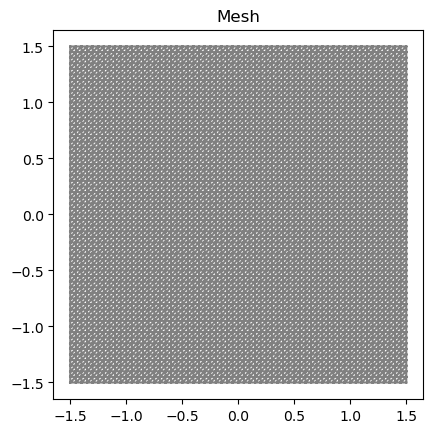

In [24]:
fn.plot(mesh, title='Mesh')
print('Degree of freedom: ', V.dim())

In [34]:
x_opt = np.array([50., 0., 0., 0., 0.])
# x_opt = np.array([22.39571205, 46.41181807, 49.64768901, 43.89231014, 37.65247073])       # Optimized for I_0 = 200, alpha = 0.3, set 1, b = 10^(-4)
# x_opt = np.array([21.19567472, 48.72482769, 49.01709614, 42.92404163, 38.13835983])       # Optimized for I_0 = 250, alpha = 0.3, set 1
# x_opt = np.array([77.74421502, 52.81290923, 35.43391017, 23.57268236, 10.2286524])        # Optimized for I_0 = 200, alpha = 0.3, set 2
# x_opt = np.array([94.7705538 , 64.83091031, 44.19357984, 29.41601532, 14.55416751])       # Optimized for I_0 = 250, alpha = 0.3, set 2
# x_opt = np.array([26.58514435, 43.45663502, 45.8251038 , 43.68162209, 40.45149474])         # Optimized for I_0 = 200, alpha = 0.3, set 1, b = 10^(-3)
# x_opt = np.array([ 66.1251,  51.9678, 0., -30.5733592, -51.3337421])                        # Optimized for I_0 = 200, alpha = 0.8
omega = np.array([20 * np.pi, 30 * np.pi, 40 * np.pi, 50 * np.pi, 60 * np.pi])
size_omega = len(omega)
list_i_prime_funcs = np.array([omega[i] * np.cos(omega[i] * simulation_times) for i in range(size_omega)])
i_true_time = x_opt.dot(list_i_prime_funcs)
f_true = space_time_mult(i_true_time, u_init, M_matrix, simulation_times)
# Zero vectors:
zero_vec = init_vector(M_matrix, 0)
zero_time_vec = init_time_vector(M_matrix, simulation_times, 0)

In [35]:
# Parameter:
c_expr = fn.Constant(c)
alpha = 0.3
# alpha = 0.8
b = (-(2 * c) / np.cos(np.pi * (alpha + 1)/ 2))
print(b)
# b = 31.54/1e3
b = 66.08/1e3
parameter = [c_expr, b, alpha]

66.08067793755801


In [36]:
# Observation operator:
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
B_matrix = fn.assemble(fn.inner(u_trial('+'), u_test('+')) * ds(1))
_misfit = WaveSpaceTimeStateObservation(V, simulation_times, simulation_times, B_matrix)

# Prior distribution:
gamma = 0.1
delta = 10.
_prior = BiLaplacianPrior(V, gamma, delta)
from WaveSolver import *
WaveNewModel = WaveInverseDamped(V, simulation_times, _misfit, _prior, parameter)

In [37]:
design = i_true_time
X_zero = WaveNewModel.generate_vector()
X_zero[PARAMETER][:] = u_init[:]
MAX = np.sqrt(integrate_time_vectors(WaveNewModel.misfit.p_obs, WaveNewModel.misfit.p_obs, B_matrix, simulation_times))
WaveNewModel.solveFwd(X_zero[STATE], X_zero, design)
WaveNewModel.misfit.p_obs = X_zero[STATE].copy()
WaveNewModel.misfit.noise_variance = 0.1
parRandom.normal_perturb(WaveNewModel.misfit.noise_variance, WaveNewModel.misfit.p_obs)
print(WaveNewModel.cost(X_zero))

[5341.6488757846955, 5341.632953806384, 0.015921978311421867]


In [38]:
from Jacobian import *
design = i_true_time
J_new = Jacobian_PAT(WaveNewModel, design)
H_new = Hessian_PAT(WaveNewModel, design)

In [39]:
k = 80
p = 20
print( "Single Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k,p))
Omega = MultiVector(X_zero[PARAMETER], k + p)
parRandom.normal(1., Omega)
lmbda, Z = singlePassG(H_new, _prior.R, _prior.Rsolver, Omega, k)
_posterior = GaussianLRPosterior(_prior, lmbda, Z)

Single Pass Algorithm. Requested eigenvectors: 80; Oversampling 20.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forwar

In [40]:
X_iter_2 = WaveNewModel.generate_vector()
solution = np.load('data_function/bi_03_200_opt_103.npy')
u_comp = init_vector_numpy(solution)
X_iter_2[PARAMETER][:] = u_comp[:]
SteinhaugSolver = CGSolverSteihaug()
SteinhaugSolver.set_operator(J_new)
SteinhaugSolver.set_preconditioner(_posterior.Hlr)
SteinhaugSolver.parameters["print_level"] = 1
SteinhaugSolver.parameters["rel_tolerance"] = 1e-4
SteinhaugSolver.parameters["abs_tolerance"] = 0.005
SteinhaugSolver.parameters["max_iter"] = 1000
SteinhaugSolver.parameters["zero_initial_guess"] = False
SteinhaugSolver.solve(X_iter_2[PARAMETER], J_new.M_b)

 Iteration :  0  (B r, r) =  294.48112915253085
 Iteration :  1  (B r, r) =  1.5021116194384971
 Iteration :  2  (B r, r) =  0.013503472552686658
 Iteration :  3  (B r, r) =  8.218612919315622e-05
 Iteration :  4  (B r, r) =  4.44670988591839e-07
Relative/Absolute residual less than tol
Converged in  4  iterations with final norm  0.0006668365531311545


Relative L2 error:  0.4363062237490298


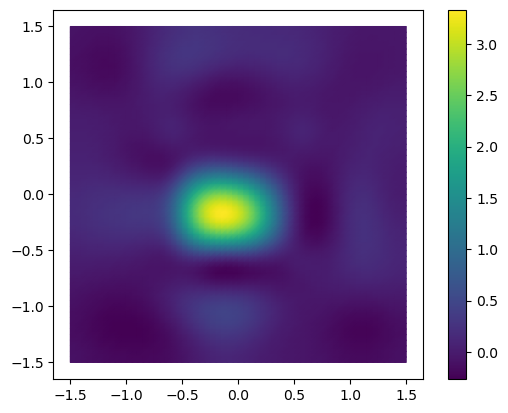

In [41]:
diff = X_iter_2[PARAMETER] - X_zero[PARAMETER]
norm = np.sqrt(diff.inner(M_matrix * diff))
norm_zero = np.sqrt(X_zero[PARAMETER].inner(M_matrix * X_zero[PARAMETER]))
print('Relative L2 error: ', norm/norm_zero)
nb.plot(fn.Function(V, X_iter_2[PARAMETER]), colorbar=False, show_axis='on')
plt.colorbar(pad = 0.05)
plt.show()

In [42]:
# Export solution to numpy:
np.save('data_function/bi_03_50_20init_103_noise001.npy', X_iter_2[PARAMETER][:])

In [8]:
# Check result:
solution = np.load('data_function/bi_08_200_opt_103.npy')
u_comp = init_vector_numpy(solution)
diff = u_comp - X_zero[PARAMETER]
norm_sub = np.sqrt(diff.inner(M_matrix_sub * diff))
norm_zero_sub = np.sqrt(X_zero[PARAMETER].inner(M_matrix_sub * X_zero[PARAMETER]))

norm_full = np.sqrt(diff.inner(M_matrix * diff))
norm_zero_full = np.sqrt(X_zero[PARAMETER].inner(M_matrix * X_zero[PARAMETER]))
# print('Relative L2 error sub : ', norm_sub /norm_zero_sub  * 100)
print('Relative L2 error full: ', norm_full/norm_zero_full * 100)

Relative L2 error full:  39.67799466947529


In [30]:
np.array([ 66.1251,  51.9678, 0., -30.5733592, -51.3337421])/200

array([ 0.3306255 ,  0.259839  ,  0.        , -0.1528668 , -0.25666871])

In [32]:
import numpy as np
x = np.array([86.26273311, 41.98872398, 29.45342825, 23.30126577, 18.99384889])/200
x = np.array([85.90138389, 41.95034421, 30.3213248 , 23.05318738, 18.77375973])/200
print(x)

[0.42950692 0.20975172 0.15160662 0.11526594 0.0938688 ]
